# VS Code + AgentCore Gateway: Serverless OAuth Proxy

## Overview

This notebook deploys a **serverless OAuth CIMD proxy** using API Gateway + Lambda,
eliminating the need for developers to run local proxy and callback servers.

### Architecture

<div style="max-width:600px">

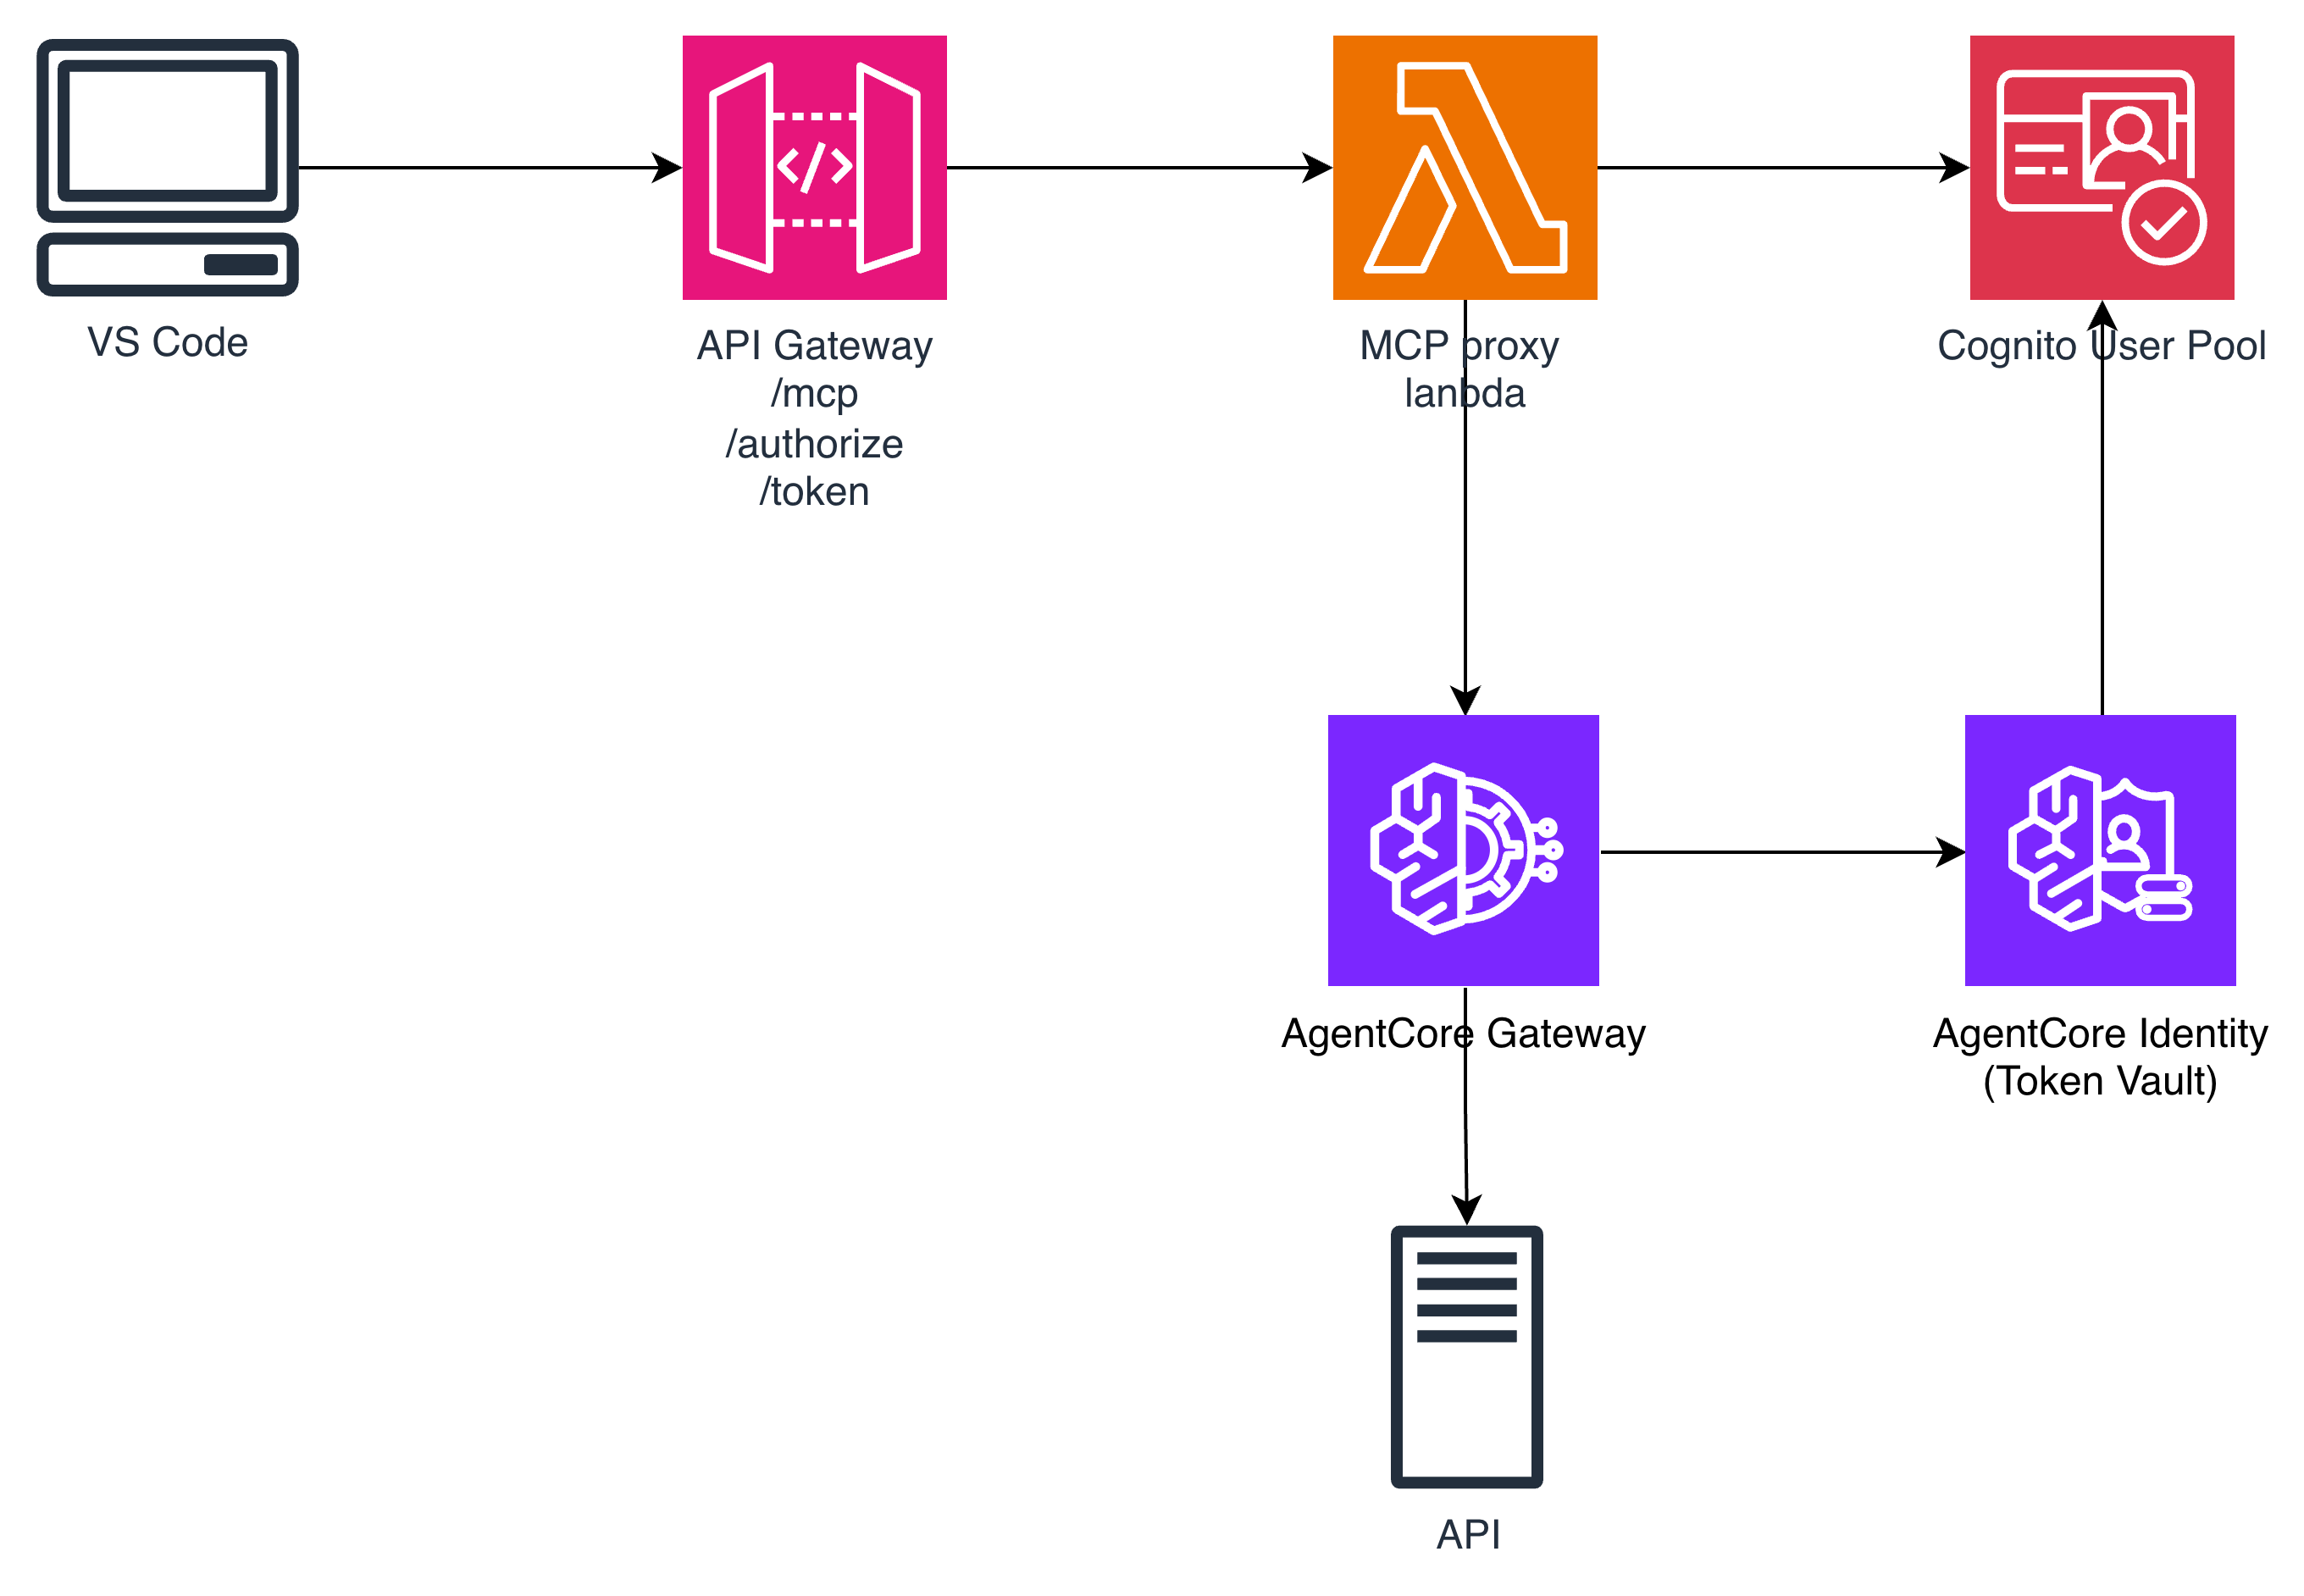

</div>

### What This Deploys

1. **API Gateway** - Public endpoint for VS Code to connect to
2. **MCP Proxy Lambda** - OAuth metadata, CIMD support, callback interception, token proxying, MCP forwarding
3. **3LO Callback Lambda** - Outbound OAuth callbacks, CompleteResourceTokenAuth
4. **Cognito User Pool** - JWT tokens for inbound authentication
5. **AgentCore Gateway** - MCP server with Confluence target

## Step 1: Setup

In [ ]:
# Install dependencies
!pip3 install -r requirements.txt --quiet

Deploy the CDK stack:

```bash
cd cdk
npm install
cdk deploy
```

then copy the output in the cell below replacing the content.

In [ ]:
import boto3

In [ ]:
output = """
CIMDOauth.ApiEndpoint = https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/
CIMDOauth.CallbackLambdaName = CIMDOauth-McpCallbackLambdaAE4B86C1-RAXEf2zFpKyK
CIMDOauth.CognitoDomain = agentcore-cimd
CIMDOauth.CognitoDomainUrl = https://agentcore-cimd.auth.eu-west-1.amazoncognito.com
CIMDOauth.DiscoveryUrl = https://cognito-idp.eu-west-1.amazonaws.com/eu-west-1_Udqf8XSzw/.well-known/openid-configuration
CIMDOauth.Gateway = agentcore-mcp-gateway-cimd-twrazqpjlk
CIMDOauth.M2MClientId = 8vu2gm5jtvtfj9cbr65ijagbl
CIMDOauth.ProxyLambdaName = CIMDOauth-McpProxyLambda5036A849-l0tQGoKHRtnx
CIMDOauth.UserPoolArn = arn:aws:cognito-idp:eu-west-1:416075262792:userpool/eu-west-1_Udqf8XSzw
CIMDOauth.UserPoolId = eu-west-1_Udqf8XSzw
CIMDOauth.VSCodeMcpConfig = {
  "servers": {
    "agentcore-confluence": {
      "type": "http",
      "url": "https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/mcp",
      "headers": {
        "MCP-Protocol-Version": "2025-11-25"
      }
    }
  }
}
"""

In [ ]:
config = {}
for el in output.split("\n"):
    if "=" in el:
        key, value = el.split("=", 1)
        config[key.strip().replace("CIMDOauth.", "")] = value.strip()

## Step 1: Create Cognito User

In [ ]:
COGNITO_USERNAME = "vscode-user@example.com"
COGNITO_PASSWORD = "TempPassword123!"

cognito = boto3.client("cognito-idp")
user_pool_id = config["UserPoolId"]
try:
    cognito.admin_create_user(
        UserPoolId=user_pool_id,
        Username=COGNITO_USERNAME,
        TemporaryPassword=COGNITO_PASSWORD,
        MessageAction="SUPPRESS",
        UserAttributes=[
            {"Name": "email", "Value": f"{COGNITO_USERNAME}"},
            {"Name": "email_verified", "Value": "true"},
        ],
    )
    cognito.admin_set_user_password(
        UserPoolId=user_pool_id,
        Username=COGNITO_USERNAME,
        Password=COGNITO_PASSWORD,
        Permanent=True,
    )
    print(f"✓ User created: {COGNITO_USERNAME}")
except cognito.exceptions.UsernameExistsException:
    print(f"✓ User exists: {COGNITO_USERNAME}")

## Step 2: Enter Atlassian OAuth Credentials

Copy the `.env.template` file to an `.env` file and fill in the required information from your Atlassian app.
Execute the following cell to load the values in the notebook.

In [ ]:
import dotenv
import os

dotenv.load_dotenv(override=True)

ATLASSIAN_CLIENT_ID = os.environ.get("ATLASSIAN_CLIENT_ID", None)
ATLASSIAN_CLIENT_SECRET = os.environ.get("ATLASSIAN_CLIENT_SECRET", None)
ATLASSIAN_TENANT = os.environ.get("ATLASSIAN_TENANT", None)

if ATLASSIAN_CLIENT_ID is None:
    print("⚠️  Replace placeholder values with your Atlassian OAuth credentials")
else:
    print("✓ Atlassian credentials configured")

## Step 3: Create Atlassian Credential Provider

In [ ]:
import boto3

client = boto3.client("bedrock-agentcore-control")

In [ ]:
credential_provider_name = "Atlassian_1"
atlassian_provider = {}

In [ ]:
atlassian_provider = client.create_oauth2_credential_provider(
    name=credential_provider_name,
    credentialProviderVendor="AtlassianOauth2",
    oauth2ProviderConfigInput={
        "atlassianOauth2ProviderConfig": {
            "clientId": ATLASSIAN_CLIENT_ID,
            "clientSecret": ATLASSIAN_CLIENT_SECRET,
        }
    },
)

In [ ]:
sts = boto3.client("sts")
region = boto3.session.Session().region_name
account = sts.get_caller_identity()["Account"]

credential_provider_arn = (
    atlassian_provider.get("credentialProviderArn", None)
    or f"arn:aws:bedrock-agentcore:{region}:{account}:token-vault/default/oauth2credentialprovider/{credential_provider_name}"
)
agentcore_callback_url = atlassian_provider.get("callbackUrl", None)

print(f"✓ Credential Provider: {credential_provider_arn}")
print(f"\n{'=' * 60}")
print("⚠️  Register this callback URL in your Atlassian app:")
print(f"   {agentcore_callback_url}")
print(f"{'=' * 60}")

## Step 4: Create Confluence Target

In [ ]:
import json

confluence_openapi_spec = {
    "openapi": "3.0.0",
    "info": {"title": "Confluence Cloud API", "version": "1.0.0"},
    "servers": [{"url": "https://api.atlassian.com/ex/confluence"}],
    "paths": {
        "/{cloudId}/wiki/api/v2/spaces": {
            "get": {
                "operationId": "getSpaces",
                "summary": "Get all Confluence spaces",
                "security": [{"BearerAuth": []}],
                "parameters": [
                    {
                        "name": "cloudId",
                        "in": "path",
                        "required": True,
                        "schema": {"type": "string"},
                    },
                    {
                        "name": "limit",
                        "in": "query",
                        "schema": {"type": "integer", "default": 25},
                    },
                ],
                "responses": {"200": {"description": "List of spaces"}},
            }
        },
        "/{cloudId}/wiki/api/v2/pages": {
            "get": {
                "operationId": "getPages",
                "summary": "Get Confluence pages",
                "security": [{"BearerAuth": []}],
                "parameters": [
                    {
                        "name": "cloudId",
                        "in": "path",
                        "required": True,
                        "schema": {"type": "string"},
                    },
                    {"name": "space-id", "in": "query", "schema": {"type": "string"}},
                    {
                        "name": "limit",
                        "in": "query",
                        "schema": {"type": "integer", "default": 25},
                    },
                ],
                "responses": {"200": {"description": "List of pages"}},
            }
        },
    },
    "components": {
        "securitySchemes": {"BearerAuth": {"type": "http", "scheme": "bearer"}}
    },
}

CONFLUENCE_SCOPES = [
    "read:space:confluence",
    "read:page:confluence",
    "read:confluence-content.all",
    "offline_access",
]
api_endpoint = config["ApiEndpoint"]
gateway_id = config["Gateway"]
DEFAULT_RETURN_URL = f"{api_endpoint}oauth2/callback"

target_response = client.create_gateway_target(
    name="Confluence",
    description="Confluence Cloud API with 3LO OAuth",
    gatewayIdentifier=gateway_id,
    credentialProviderConfigurations=[
        {
            "credentialProviderType": "OAUTH",
            "credentialProvider": {
                "oauthCredentialProvider": {
                    "providerArn": credential_provider_arn,
                    "grantType": "AUTHORIZATION_CODE",
                    "defaultReturnUrl": DEFAULT_RETURN_URL,
                    "scopes": CONFLUENCE_SCOPES,
                }
            },
        }
    ],
    targetConfiguration={
        "mcp": {"openApiSchema": {"inlinePayload": json.dumps(confluence_openapi_spec)}}
    },
)
target_id = target_response["targetId"]
print(f"✓ Confluence target: {target_id}")

## Step 5: Get Atlassian Cloud ID

In [ ]:
import requests

if ATLASSIAN_TENANT and not ATLASSIAN_TENANT.startswith("<"):
    try:
        url = f"https://{ATLASSIAN_TENANT}.atlassian.net/_edge/tenant_info"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        tenant_info = response.json()
        ATLASSIAN_CLOUD_ID = tenant_info.get("cloudId")
        print("Cloud Id")
        print(ATLASSIAN_CLOUD_ID)
    except Exception as e:
        print(f"Could not retrieve Cloud ID: {e}")
        ATLASSIAN_CLOUD_ID = "<your-cloud-id>"
else:
    ATLASSIAN_CLOUD_ID = "<your-cloud-id>"
    print("⚠️  Set ATLASSIAN_TENANT to retrieve Cloud ID")

## Step 6: VS Code Configuration

No local servers needed! Just configure VS Code to point to the API Gateway.

In [ ]:
print(
    json.dumps(
        {
            "servers": {
                "agentcore-confluence": {
                    "type": "http",
                    "url": config["ApiEndpoint"] + "mcp",
                    "headers": {"MCP-Protocol-Version": "2025-11-25"},
                }
            }
        },
        indent=2,
    )
)

----

## Cleanup (Optional)

Run this cell to delete all resources created by this notebook.

In [ ]:
client = boto3.client("bedrock-agentcore-control")


def cleanup():
    """Delete all resources created by this notebook."""
    print("Cleaning up resources...")
    # Delete Gateway target and gateway
    targets = client.list_gateway_targets(gatewayIdentifier=config["Gateway"])["items"]
    try:
        for t in targets:
            print(
                f" Deleting target {t['targetId']} for gateway {config['Gateway']}",
                end="",
            )
            client.delete_gateway_target(
                gatewayIdentifier=config["Gateway"], targetId=t["targetId"]
            )
            print(" done")

    except Exception:
        pass

    # Delete credential provider
    try:
        client.delete_oauth2_credential_provider(name=credential_provider_name)
        print("✓ Deleted Credential Provider")
    except Exception:
        pass


# Uncomment to run cleanup:
cleanup()

To remove the remaining resources run:

```bash
cd cdk
cdk destroy
```

# How does it work

In [ ]:
client = boto3.client("cognito-idp")

When connecting with a client that support CIMD you set the client_id to an URL. That URL would expose the information used by the process. In this example we use VS Code and this is the VS Code client_id:

In [ ]:
client_id = "https://vscode.dev/oauth/client-metadata.json"

Since Cognito has a limited character set support for client_id, we cannot store this client id directly. Instead we encode it in base64

In [ ]:
import requests

cimd_manifest = requests.get(client_id).json()
cimd_manifest

In [ ]:
import base64

USER_POOL_ID = "eu-west-1_WEJy1WGkY"
client_id = "https://vscode.dev/oauth/client-metadata.json"
user_pool = client.create_user_pool_client(
    UserPoolId=USER_POOL_ID,
    ClientName=str(base64.b64encode(bytes(client_id, "utf8")).decode("ascii")),
    CallbackURLs=cimd_manifest["redirect_uris"],
    AllowedOAuthFlows=["code"],
    ExplicitAuthFlows=[
        "ALLOW_USER_SRP_AUTH",  # Enable SRP-based authentication
        "ALLOW_REFRESH_TOKEN_AUTH",  # Enable token refresh
    ],
    AllowedOAuthScopes=[
        "openid",
        "profile",
        "email",
        "agentcore-gateway/mcp.read",
        "agentcore-gateway/mcp.write",
    ],
    SupportedIdentityProviders=["COGNITO"],
)

In [ ]:
client.list_resource_servers(UserPoolId=USER_POOL_ID, MaxResults=50)["ResourceServers"][
    0
]

Now, when a new request arrive from a CIMD client, we look up all the clients in the pool and we match their name with the encoded version of the client_id we get in the request.

In [ ]:
base64.b64encode(b"https://vscode.dev/oauth/client-metadata.json").decode("ascii")

In [ ]:
clients = client.list_user_pool_clients(UserPoolId=USER_POOL_ID)["UserPoolClients"]

In [ ]:
{c["ClientName"]: c["ClientId"] for c in clients}

Next, we need to update the AgentCore Gateway, with the newly created Cognito User Pool client_id.

In [ ]:
ac = boto3.client("bedrock-agentcore-control")

In [ ]:
resp = ac.get_gateway(gatewayIdentifier="agentcore-mcp-gateway-cimd-twrazqpjlk")

In [ ]:
resp

In [ ]:
resp.pop("ResponseMetadata")
resp["gatewayIdentifier"] = resp["gatewayId"]
resp.pop("gatewayId")
resp.pop("gatewayArn")
resp.pop("gatewayUrl")
resp.pop("createdAt")
resp.pop("updatedAt")
resp.pop("status")
resp.pop("workloadIdentityDetails")
resp

In [ ]:
resp["authorizerConfiguration"]["customJWTAuthorizer"]["allowedClients"].append(
    user_pool["UserPoolClient"]["ClientId"]
)

In [ ]:
ac.update_gateway(**resp)

Finally, we are ready to test connecting to the MCP server

In [ ]:
GATEWAY_URL = "https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/mcp"

In [ ]:
import json
import requests

response = requests.post(
    GATEWAY_URL,
    headers={"Content-Type": "application/json"},
    data=json.dumps({"jsonrpc": "2.0", "id": 2, "method": "tools/list", "params": {}}),
)

As expected, we get an error with an URL about the authorizer info

In [ ]:
print(response.text)
print(response.headers)

In [ ]:
"https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/.well-known/oauth-authorization-server"

In [ ]:
import pkce

code_verifier, code_challenge = pkce.generate_pkce_pair()

From the oauth protected resource manifest we can find the authorize endpoint to call to get the access token. Then we build the authorization URL:

In [ ]:
f"https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/authorize?client_id=https%3A%2F%2Fvscode.dev%2Foauth%2Fclient-metadata.json&response_type=code&code_challenge={code_challenge}&code_challenge_method=S256&scope=openid+email+agentcore-gateway%2Fmcp.read+agentcore-gateway%2Fmcp.write&resource=https%3A%2F%2Fm9k3p4ljr2.execute-api.eu-west-1.amazonaws.com%2Fmcp&redirect_uri=http%3A%2F%2F127.0.0.1%3A33418&state=Yk%2FLbnhh1Ht869Ua11VXKw%3D%3D"

If auth is successful, the browser will be redirected to an url. Since this has not been executed by VS Code, there is no endpoint running. We get the URL and extract the authorization code to complete the Oauth2 flow:

In [ ]:
url = "http://127.0.0.1:33418/?code=43350756-e013-4340-bb50-12a4b72e265d&state=Yk%2FLbnhh1Ht869Ua11VXKw%3D%3D"

In [ ]:
from urllib.parse import parse_qs

r = parse_qs(url.split("?")[1])
r

In [ ]:
code = r["code"][0]

In [ ]:
response = requests.post(
    "https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com/token",
    headers={"Content-Type": "application/x-www-form-urlencoded"},
    data={
        "client_id": "https://vscode.dev/oauth/client-metadata.json",
        "grant_type": "authorization_code",
        "code": code,
        "redirect_uri": "http://127.0.0.1:33418/",
        "code_verifier": code_verifier,
        "resource": "https://m9k3p4ljr2.execute-api.eu-west-1.amazonaws.com",
    },
)

In [ ]:
tokens = response.json()

In [ ]:
access_token = tokens["access_token"]

Now that we have the access_token we can invoke the MCP again:

In [ ]:
import json
import requests

response = requests.post(
    GATEWAY_URL,
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {access_token}",
    },
    data=json.dumps({"jsonrpc": "2.0", "id": 2, "method": "tools/list", "params": {}}),
)